# 01 — Préparation des données & Feature Engineering

Ce notebook couvre **Milestone 2**.

- Charge `application_train.csv`
- Nettoie NaN/Inf
- Ajoute quelques features simples (à compléter selon le kernel choisi)
- Sauvegarde en parquet dans `data/processed/`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.insert(0, os.path.abspath(".."))  # monte d'un niveau (../)

from src.config import PATHS
from src.data import load_csv, save_parquet
from src.features import basic_cleaning, add_simple_features

print("Data raw:", PATHS.data_raw)
print("Data processed:", PATHS.data_processed)


Data raw: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\raw
Data processed: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\processed


## 1) Charger les données

⚠️ Remplace le chemin par votre fichier complet `application_train.csv`.

Pour démonstration, ce dépôt peut contenir un fichier `application_train_head.csv` (échantillon).

In [2]:
train_path_full = PATHS.data_raw / "application_train.csv"
train_path_sample = PATHS.data_raw / "application_train_head.csv"

test_path_full = PATHS.data_raw / "application_test.csv"
test_path_sample = PATHS.data_raw / "application_test_head.csv"

In [3]:
path = train_path_full if train_path_full.exists() else train_path_sample
df = load_csv(path)
print('Training data shape: ', df.shape)
print(df.columns[:10])
df.head()

Training data shape:  (99999, 122)
Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY'],
      dtype='object')


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Testing data features
path_test = test_path_full if test_path_full.exists() else test_path_sample
df_test = load_csv(path_test)
print('Training data shape: ', df_test.shape)
print(df_test.columns[:10])
df_test.head()

Training data shape:  (48744, 121)
Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE'],
      dtype='object')


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df['TARGET'].value_counts()

TARGET
0    91906
1     8093
Name: count, dtype: int64

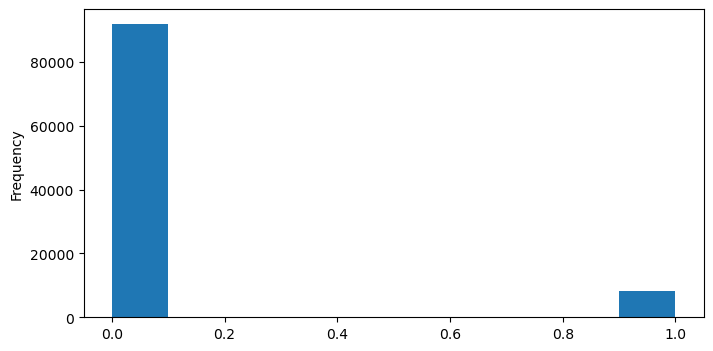

In [6]:
plt.figure(figsize = (8, 4))
df['TARGET'].astype(int).plot.hist();

## 2) Exploration des données / Nettoyage de base

In [7]:
df = basic_cleaning(df)
df.isna().mean().sort_values(ascending=False).head(10)


COMMONAREA_MEDI             0.697317
COMMONAREA_AVG              0.697317
COMMONAREA_MODE             0.697317
NONLIVINGAPARTMENTS_MODE    0.692747
NONLIVINGAPARTMENTS_AVG     0.692747
NONLIVINGAPARTMENTS_MEDI    0.692747
LIVINGAPARTMENTS_MODE       0.682647
LIVINGAPARTMENTS_AVG        0.682647
LIVINGAPARTMENTS_MEDI       0.682647
FONDKAPREMONT_MODE          0.682177
dtype: float64

In [8]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [9]:
# Number of unique classes in each object column
df.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [10]:
# # one-hot encoding of categorical variables
# df = pd.get_dummies(df)
# df_test = pd.get_dummies(df_test)

# print('Training Features shape: ', df.shape)
# print('Testing Features shape: ', df_test.shape)

In [11]:
(df['DAYS_BIRTH'] / -365).describe()

count    99999.000000
mean        43.908125
std         11.968022
min         21.030137
25%         33.946575
50%         43.128767
75%         53.884932
max         69.043836
Name: DAYS_BIRTH, dtype: float64

In [12]:
df['DAYS_EMPLOYED'].describe()

count     99999.000000
mean      63292.887289
std      140840.244402
min      -17531.000000
25%       -2758.000000
50%       -1219.000000
75%        -291.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

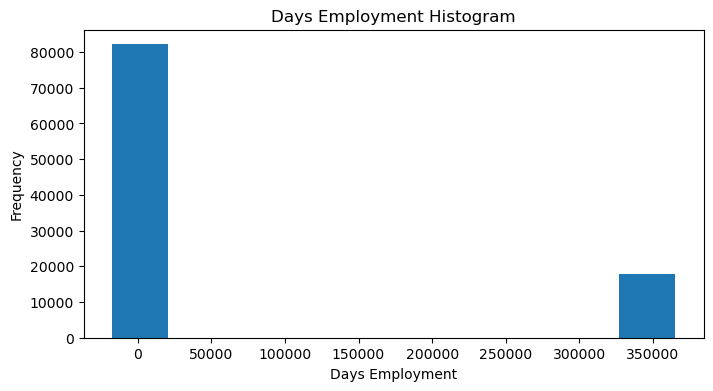

In [13]:
plt.figure(figsize = (8, 4))
df['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [14]:
app_train = df
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.50% of loans
There are 17865 anomalous days of employment


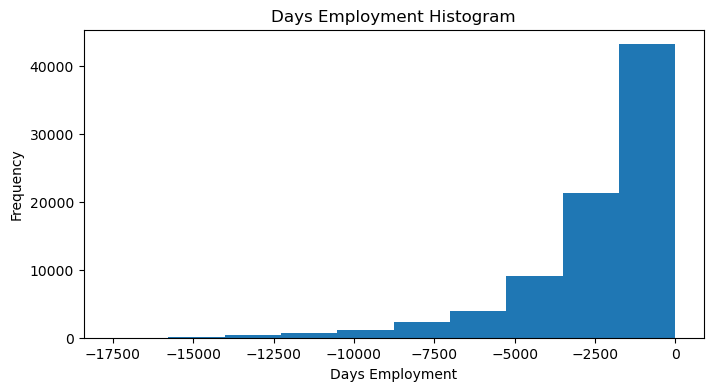

In [15]:
plt.figure(figsize = (8, 4))
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [16]:
app_test = df_test
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 9274 anomalies in the test data out of 48744 entries


C:\Users\dabri\AppData\Local\Temp\ipykernel_47072\80739435.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)


In [17]:
# Find correlations with the target and sort

numeric_df = app_train.select_dtypes(include=['int64', 'float64'])
correlations = numeric_df.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DEF_30_CNT_SOCIAL_CIRCLE       0.035462
DEF_60_CNT_SOCIAL_CIRCLE       0.036548
REG_CITY_NOT_LIVE_CITY         0.036816
DAYS_REGISTRATION              0.039269
OWN_CAR_AGE                    0.043349
FLAG_DOCUMENT_3                0.043774
FLAG_EMP_PHONE                 0.044350
REG_CITY_NOT_WORK_CITY         0.048272
DAYS_ID_PUBLISH                0.051792
DAYS_LAST_PHONE_CHANGE         0.053015
REGION_RATING_CLIENT           0.061597
REGION_RATING_CLIENT_W_CITY    0.062815
DAYS_EMPLOYED                  0.072738
DAYS_BIRTH                     0.076839
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178742
EXT_SOURCE_2                 -0.161656
EXT_SOURCE_1                 -0.153105
FLOORSMAX_AVG                -0.044961
FLOORSMAX_MEDI               -0.044462
FLOORSMAX_MODE               -0.043756
AMT_GOODS_PRICE              -0.040318
REGION_POPULATION_RELATIVE   -0.038405


In [18]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07683872347151433)

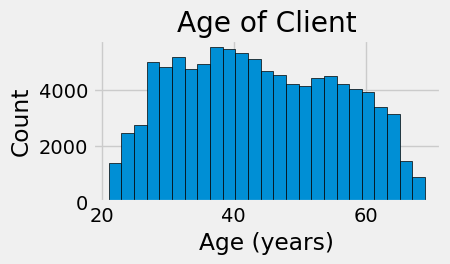

In [19]:
# Set the style of plots
plt.style.use('fivethirtyeight')
plt.figure(figsize = (4, 2))

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

In [20]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.153105,-0.161656,-0.178742,-0.076839
EXT_SOURCE_1,-0.153105,1.000000,0.215801,0.185798,0.604018
EXT_SOURCE_2,-0.161656,0.215801,1.000000,0.108796,0.092396
EXT_SOURCE_3,-0.178742,0.185798,0.108796,1.000000,0.209851
DAYS_BIRTH,-0.076839,0.604018,0.092396,0.209851,1.000000


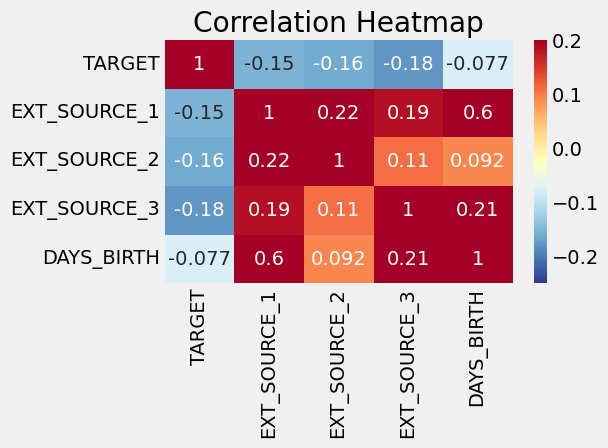

In [21]:
import seaborn as sns
plt.figure(figsize = (5, 3))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.2)
plt.title('Correlation Heatmap');

## 3) Feature engineering (exemples)

👉 Ici, vous intégrez les agrégations/ratios inspirés du kernel choisi.

In [22]:
df_fe = add_simple_features(df)
df_fe.shape


(99999, 126)

In [23]:
df_fe.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM,RATIO_CREDIT_INCOME,RATIO_ANNUITY_CREDIT,RATIO_EMPLOYED_BIRTH
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,False,2.007889,0.060749,-0.067329
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,False,4.790750,0.027598,-0.070862
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,False,2.000000,0.050000,-0.011814
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,False,2.316167,0.094941,-0.159905
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,False,4.222222,0.042623,-0.152418


## 4) Sauvegarde dataset prêt pour la modélisation

In [24]:
out = PATHS.data_processed / "train_fe.parquet"
save_parquet(df_fe, out)
print("Saved to:", out)


Saved to: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\processed\train_fe.parquet
